In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [4]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "qkv_bias": False,
    "drop_rate_mha": 0.1,
    "drop_rate_shortcut": 0.1,
    "drop_rate_embedding": 0.1
}

In [5]:
import torch
from scripts.gpt import GPTModel

torch.manual_seed(123)
gpt = GPTModel(GPT_CONFIG_124M)
gpt.eval()


GPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
   

In [42]:
import tiktoken

def text_to_tokens_ids(text: str, tokenizer):
    encoded_text = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_text = torch.tensor(encoded_text).unsqueeze(0)
    return encoded_text

def tokens_ids_to_text(tokens: torch.tensor, tokenizer):
    flatten_text = tokens.squeeze(0)
    return tokenizer.decode(flatten_text.tolist())

start_context = "Every effort moves you"

tokenizer = tiktoken.get_encoding("gpt2")
print(text_to_tokens_ids(start_context, tokenizer))
tokens_ids_to_text(text_to_tokens_ids(start_context, tokenizer), tokenizer)

tensor([[6109, 3626, 6100,  345]])


'Every effort moves you'

In [7]:
from scripts.text_generation import generate_simple_text

tokens = text_to_tokens_ids(start_context, tokenizer)
tokens_ids_output = generate_simple_text(
    model=gpt,
    idx=tokens,
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"]
)

print(f"Model output: {tokens_ids_to_text(tokens_ids_output, tokenizer)}")

Model output: Every effort moves you rentingetic minion cones477243 therepo expression syllcigarettesdevelopChristmas1969att


### Prepare text generation loss

In [8]:
tensor1 = text_to_tokens_ids("Every effort moves", tokenizer)
tensor2 = text_to_tokens_ids("I really like", tokenizer)

input = torch.concat([
    tensor1,
    tensor2
])

input

tensor([[6109, 3626, 6100],
        [  40, 1107,  588]])

In [9]:
tensor1 = text_to_tokens_ids(" effort moves you", tokenizer)
tensor2 = text_to_tokens_ids(" really like you", tokenizer)

targets = torch.concat([
    tensor1,
    tensor2
])

targets

tensor([[3626, 6100,  345],
        [1107,  588,  345]])

In [10]:
with torch.no_grad():
    logits = gpt(input)
probs = torch.softmax(logits, dim=-1)
print(probs.shape)

torch.Size([2, 3, 50257])


In [11]:
token_ids = torch.argmax(probs, dim=-1, keepdim=True)
print(token_ids)

tensor([[[16835],
         [24415],
         [44376]],

        [[49906],
         [29669],
         [41751]]])


In [12]:
print(f"Output for batch 1: {tokens_ids_to_text(targets[0], tokenizer)}")
print(f"Output for batch 1: {tokens_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Output for batch 1:  effort moves you
Output for batch 1:  Train iteration inaction


In [13]:
text_idx = 0
target_probas_1 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)
text_idx = 1
target_probas_2 = probs[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([4.0571e-05, 2.6047e-05, 8.8406e-06])
Text 2: tensor([1.0337e-05, 5.5172e-05, 1.0389e-05])


In [14]:
log_probs = torch.log(torch.cat((target_probas_1, target_probas_2)))

In [15]:
neg_log_probs = -log_probs
avg_neg_log_probs = torch.mean(neg_log_probs)
avg_neg_log_probs

tensor(10.8440)

In [16]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [17]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()

print("Logits shape:", logits_flat.shape)
print("Targets shape:", targets_flat.shape)

Logits shape: torch.Size([6, 50257])
Targets shape: torch.Size([6])


In [18]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
perplexity = torch.exp(loss)
print(loss)
print(perplexity)

tensor(10.8440)
tensor(51224.1562)


In [19]:
file_path = r"C:\Users\urbii\Desktop\Projekty\Build-LLM-from-Scratch\data\the-verdict.txt"

with open(file_path, "r") as f:
    data = f.read()

print(text_to_tokens_ids(data, tokenizer))

tensor([[  40,  367, 2885,  ...,  286, 1242,  526]])


In [20]:
total_characters = len(data)
total_tokens = len(tokenizer.encode(data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [21]:
train_ratio = 0.9
train_idx = int(train_ratio*len(data))
train_data = data[:train_idx]
val_data = data[train_idx:]

In [22]:
from scripts.pretraining import create_dataloaderv1

train_dataloader = create_dataloaderv1(
    txt=train_data,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    batch_size=2,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

val_dataloader = create_dataloaderv1(
    txt=val_data,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    batch_size=2,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

print("Train loader:")
for x, y in train_dataloader:
    print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_dataloader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [43]:
def calc_loss_batch(input, target, model, device):
    input = input.to(device)
    target = target.to(device)
    output = model(input)
    loss = torch.nn.functional.cross_entropy(
        output.flatten(0, 1), target.flatten()
    )
    return loss

def calc_loss_dataloader(dataloader, model, device, num_batches=None):
    total_loss = 0
    if len(dataloader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(len(dataloader), num_batches)

    for i, (input, target) in enumerate(dataloader):
        if i < num_batches:
            loss = calc_loss_batch(input, target, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


In [24]:
device = ("cuda" if torch.cuda.is_available else "cpu")
gpt.to(device)
with torch.no_grad():
    training_loss = calc_loss_dataloader(train_dataloader, gpt, device)
    val_loss = calc_loss_dataloader(train_dataloader, gpt, device)

print(f"Training loss: {training_loss}")
print(f"Validation loss: {val_loss}")

Training loss: 10.987869686550564
Validation loss: 10.987869580586752


In [ ]:
def train_llm(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    num_epoch,
    device,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer,
    warmup_steps=0,
    initial_warmup=0.0,
    peak_lr=0.001,
):
    track_train_loss, track_val_loss, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1
    lr_increment = ((peak_lr - initial_warmup) / warmup_steps if warmup_steps > 0 else 0)
    for i in range(num_epoch):
        model.train()
        for input, target in train_dataloader:
            global_step += 1
            if global_step < warmup_steps:
                lr = initial_warmup + (global_step * lr_increment)
            else:
                lr = peak_lr
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)
            optimizer.zero_grad()
            loss = calc_loss_batch(input, target, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = eval_model(
                    train_dataloader, val_dataloader, model, device, eval_iter
                )
                track_train_loss.append(train_loss)
                track_val_loss.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch: {i+1}, step: {global_step:06d}, lr: {lr}")
                print(f"Train loss: {train_loss:.3f}, Valid loss: {val_loss:.3f}")
                print(
                    f"Training perplexity: {torch.exp(torch.tensor(train_loss)):.3f}, Valid perplexity: {torch.exp(torch.tensor(val_loss)):.3f}"
                )

        generate_and_print_sample(model, tokenizer, start_context, device)
    return track_train_loss, track_val_loss, track_tokens_seen, track_lrs


def eval_model(train_dataloader, val_dataloader, model, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_dataloader(train_dataloader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_dataloader(val_dataloader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, start_context, device):
    model.eval()
    context_length = model.pos_emb.weight.shape[0]
    input_tokens = text_to_tokens_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        output = generate_simple_text(model, input_tokens, 50, context_length)
    decoded_output = tokens_ids_to_text(output, tokenizer)
    print(decoded_output.replace("\n", " "))
    model.train()

### Model training

#### Verdict

In [31]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
start_context = "Every effort moves you"
num_of_epochs = 10

train_losses, val_losses, tokens_seen = train_llm(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    num_epoch=num_of_epochs,
    device=device,
    eval_freq=5,
    eval_iter=5,
    start_context=start_context,
    tokenizer=tokenizer)

Epoch: 1, step: 000000
Train loss: 9.821, Valid loss: 9.928
Training perplexity: 18421.133, Valid perplexity: 20504.977
Epoch: 1, step: 000005
Train loss: 8.066, Valid loss: 8.337
Training perplexity: 3184.852, Valid perplexity: 4176.978
Every effort moves you,,,,,,,,,,,,.                                     
Epoch: 2, step: 000010
Train loss: 6.624, Valid loss: 7.050
Training perplexity: 752.612, Valid perplexity: 1153.114
Epoch: 2, step: 000015
Train loss: 6.049, Valid loss: 6.604
Training perplexity: 423.658, Valid perplexity: 738.394
Every effort moves you, and,, and,,,,,,, and,.                                   
Epoch: 3, step: 000020
Train loss: 5.546, Valid loss: 6.502
Training perplexity: 256.107, Valid perplexity: 666.499
Epoch: 3, step: 000025
Train loss: 5.407, Valid loss: 6.376
Training perplexity: 223.041, Valid perplexity: 587.640
Every effort moves you, and to the to the of the picture. Gis, and I had. Gis, and, and, and, and, and I had, and, and, and, and, and, and, an

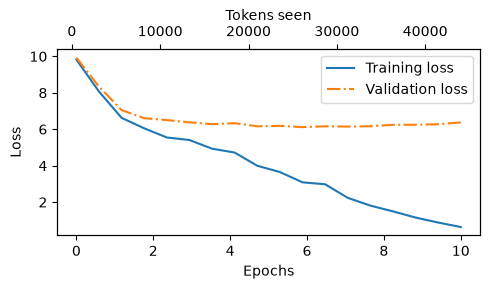

In [32]:
from scripts.utils import plot_losses

epochs_tensor = torch.linspace(0, num_of_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### Decoding strategies

In [33]:
model.to("cpu")
model.eval()

GPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
   

In [34]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_simple_text(
    model=model,
    idx=text_to_tokens_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", tokens_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




#### Temperature scaling

In [35]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [36]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [37]:
probs = torch.softmax(next_token_logits, dim=-1)
next_token_id = torch.argmax(probs).item()
inverse_vocab[next_token_id]

'forward'

In [38]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probs, 1).item()
print(inverse_vocab[next_token_id])

forward


In [39]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
    for _ in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probs)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [45]:
def softmax_with_temperature(logits, temperature):
    scaled_probas = logits / temperature
    return torch.softmax(scaled_probas, dim=-1)

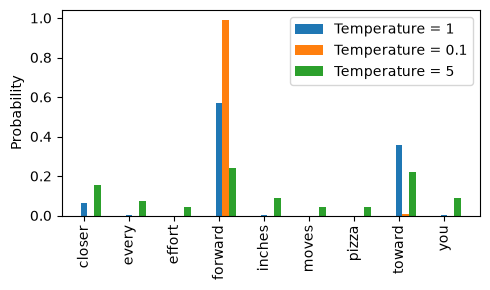

In [41]:
import matplotlib.pyplot as plt

temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
    bar_width, label=f'Temperature = {T}')
    ax.set_ylabel('Probability')
    ax.set_xticks(x)
    ax.set_xticklabels(vocab.keys(), rotation=90)
    ax.legend()
plt.tight_layout()
plt.show()

In [42]:
# With mulitnomial sampling we can assess probability of occuring particular tokens by checking its probability. It is faster than printing.
for temperature in sorted(temperatures):
    probs = softmax_with_temperature(next_token_logits, temperature)
    print(f"Temperature: {temperature}")
    print(probs)
    print_sampled_tokens(probs)
    print()

Temperature: 0.1
tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward

Temperature: 1
tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward

Temperature: 5
tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])
165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you



#### Top-k sampling

In [43]:
k=3
topk_token = torch.topk(next_token_logits, k=k).values
masked_logits = torch.where(
    next_token_logits < torch.min(topk_token),
    torch.tensor(float('-inf')),
    next_token_logits
)
probs_topk = torch.softmax(masked_logits, dim=-1)

In [40]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    model.eval()
    for _ in range(max_new_tokens):
        current_input = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(current_input)
        last_token = logits[:, -1, :]

        if top_k:
            top_k_tokens = torch.topk(last_token, k=top_k).values
            last_token = torch.where(
                last_token < torch.min(top_k_tokens),
                torch.tensor(float('-inf')),
                last_token
            )

        if temperature > 0.0:
            probs = softmax_with_temperature(last_token, temperature)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(last_token, dim=-1, keepdim=True)

        if eos_id == idx_next:
            break

        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [45]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_tokens_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", tokens_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?" I meant to do the picture--I felt nervous and uncertain.



### Saving and loading model

In [53]:
model_path = r"C:\Users\urbii\Desktop\Projekty\Build-LLM-from-Scratch\data\models\gpt_model_verdict.pth"
torch.save(model.state_dict(), model_path)

In [54]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

GPTModel(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attention): MultiHeadAttention(
   

In [56]:
model_and_optimizer_path = r"C:\Users\urbii\Desktop\Projekty\Build-LLM-from-Scratch\data\models\gpt_model_and_optimizer_verdict.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    model_and_optimizer_path
)

In [65]:
checkpoint = torch.load(model_and_optimizer_path, map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

In [66]:
start_context = "Every effort moves you"
num_of_epochs = 1

train_losses, val_losses, tokens_seen = train_llm(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    num_epoch=num_of_epochs,
    device=device,
    eval_freq=5,
    eval_iter=5,
    start_context=start_context,
    tokenizer=tokenizer)

Epoch: 1, step: 000000
Train loss: 0.470, Valid loss: 6.453
Training perplexity: 1.599, Valid perplexity: 634.489
Epoch: 1, step: 000005
Train loss: 0.337, Valid loss: 6.513
Training perplexity: 1.401, Valid perplexity: 674.098
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


### Load Openai weights

In [67]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x1f87897d280>)

In [68]:
from scripts.gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 15.4kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 681kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 45.0kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:58<00:00, 2.79MiB/s]  
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 1.74MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 699kiB/s] 
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 639kiB/s] 


In [69]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [26]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [91]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'qkv_bias': True,
 'drop_rate_mha': 0.1,
 'drop_rate_shortcut': 0.1,
 'drop_rate_embedding': 0.1}

In [92]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [33]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
        "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [34]:
import numpy as np
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.token_emb.weight = assign(gpt.token_emb.weight, params['wte'])
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.transformer_blocks[b].attention.W_query.weight = assign(
            gpt.transformer_blocks[b].attention.W_query.weight, q_w.T)
        gpt.transformer_blocks[b].attention.W_key.weight = assign(
            gpt.transformer_blocks[b].attention.W_key.weight, k_w.T)
        gpt.transformer_blocks[b].attention.W_value.weight = assign(
            gpt.transformer_blocks[b].attention.W_value.weight, v_w.T)
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.transformer_blocks[b].attention.W_query.bias = assign(
            gpt.transformer_blocks[b].attention.W_query.bias, q_b)
        gpt.transformer_blocks[b].attention.W_key.bias = assign(
            gpt.transformer_blocks[b].attention.W_key.bias, k_b)
        gpt.transformer_blocks[b].attention.W_value.bias = assign(
            gpt.transformer_blocks[b].attention.W_value.bias, v_b)
        gpt.transformer_blocks[b].attention.out_proj.weight = assign(
            gpt.transformer_blocks[b].attention.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].attention.out_proj.bias = assign(
            gpt.transformer_blocks[b].attention.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.transformer_blocks[b].ffn.layers[0].weight = assign(
            gpt.transformer_blocks[b].ffn.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.transformer_blocks[b].ffn.layers[0].bias = assign(
            gpt.transformer_blocks[b].ffn.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.transformer_blocks[b].ffn.layers[2].weight = assign(
            gpt.transformer_blocks[b].ffn.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].ffn.layers[2].bias = assign(
            gpt.transformer_blocks[b].ffn.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.transformer_blocks[b].norm1.scale = assign(
            gpt.transformer_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.transformer_blocks[b].norm1.shift = assign(
            gpt.transformer_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.transformer_blocks[b].norm2.scale = assign(
            gpt.transformer_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.transformer_blocks[b].norm2.shift = assign(
            gpt.transformer_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.final_layer.weight = assign(gpt.final_layer.weight, params["wte"])

In [105]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [106]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_tokens_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", tokens_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you along the road to the top, where the best of your talent is. You'll be rewarded for it with a great job


In [107]:
start_context = "Every effort moves you"
num_of_epochs = 1

train_losses, val_losses, tokens_seen = train_llm(
    model=gpt,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    num_epoch=num_of_epochs,
    device=device,
    eval_freq=5,
    eval_iter=5,
    start_context=start_context,
    tokenizer=tokenizer)

Epoch: 1, step: 000000
Train loss: 3.743, Valid loss: 3.560
Training perplexity: 42.239, Valid perplexity: 35.150
Epoch: 1, step: 000005
Train loss: 3.819, Valid loss: 3.560
Training perplexity: 45.555, Valid perplexity: 35.150
Every effort moves you forward.  The first step is to understand the importance of your work.  The second step is to understand the importance of your work.  The third step is to understand the importance of your work.  The fourth step is


#### Load the bigger OpenAI GPT-2 model

In [3]:
from scripts.gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="355M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json


model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [24:15<00:00, 975kiB/s]   
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 1.87MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:01<00:00, 582kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 357kiB/s]  


In [28]:
model_name = "gpt2-medium (355M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 1024,
 'n_heads': 16,
 'n_layers': 24,
 'qkv_bias': True,
 'drop_rate_mha': 0.1,
 'drop_rate_shortcut': 0.1,
 'drop_rate_embedding': 0.1}

In [29]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [35]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [46]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_tokens_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", tokens_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the natural capacity is capable," the lawyer wrote, "which permits extraordinary actions." "That includes (dressing


In [50]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
start_context = "Every effort moves you"
num_of_epochs = 10

train_losses, val_losses, tokens_seen, track_lrs = train_llm(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    num_epoch=num_of_epochs,
    device=device,
    eval_freq=5,
    eval_iter=5,
    start_context=start_context,
    tokenizer=tokenizer,
    warmup_steps=10,
    initial_warmup=0.0001,
    peak_lr=0.0004)

3.0000000000000004e-05
Epoch: 1, step: 000000, lr: 0.0001
Train loss: 10.536, Valid loss: 10.573
Training perplexity: 37651.426, Valid perplexity: 39048.746
Epoch: 1, step: 000005, lr: 0.00025
Train loss: 8.831, Valid loss: 9.073
Training perplexity: 6839.769, Valid perplexity: 8715.679
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Epoch: 2, step: 000010, lr: 0.0004
Train loss: 7.402, Valid loss: 7.732
Training perplexity: 1639.729, Valid perplexity: 2279.361
Epoch: 2, step: 000015, lr: 0.0004
Train loss: 6.339, Valid loss: 6.806
Training perplexity: 566.421, Valid perplexity: 903.498
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Epoch: 3, step: 000020, lr: 0.0004
Train loss: 5.955, Valid loss: 6.570
Training perplexity: 385.851, Valid perplexity: 713.059
Epoch: 3, step: 000025, lr: 0.0004
Train loss: 10.138, Valid loss: 10.835
Training perplexity: 25286.242, Valid perplexity: 50759.359
Every effort moves you, the, the, the, the, th